# 🧠 Phase 4 — CNN-LSTM Model (Main Architecture)
**Backbone:** ResNet-50 → LSTM with Attention
**This is the core model** that captures spatial (CNN) + temporal (LSTM) patterns.

| Component | Details |
|---|---|
| CNN Encoder | ResNet-50 (frozen early layers) |
| Temporal Model | Bi-directional LSTM (2 layers, 256 hidden) |
| Pooling | Soft Attention |
| Classifier | 2-layer MLP |

In [1]:
import sys, os
sys.path.insert(0, "../src")
import torch, torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm
from sklearn.metrics import classification_report
import numpy as np

from utils import set_seed, get_device, CLASS_NAMES, plot_training_curves, plot_confusion_matrix
from dataset import get_dataloader
from model import CNNLSTM
from sklearn.metrics import confusion_matrix

set_seed(42)
device = get_device()


c:\Users\Abhinav\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU | VRAM: 6.4 GB


In [2]:
# ── Config ───────────────────────────────────────────────
BATCH_SIZE = 8     # RTX 3050 6GB — safe at 8; try 16 if fast enough
EPOCHS = 10
LR = 1e-4
NUM_FRAMES = 20
DATA_ROOT = "../data/raw"
SAVE_PATH = "../models/saved/cnn_lstm_best.pth"

train_loader, _ = get_dataloader(DATA_ROOT, "train", BATCH_SIZE, num_workers=4, num_frames=NUM_FRAMES)
val_loader,   _ = get_dataloader(DATA_ROOT, "val",   BATCH_SIZE, num_workers=4, num_frames=NUM_FRAMES)
print("✅ Data loaded.")


  ✅ Loaded 21 class names from lable.txt
  [train] 939 videos | 21 classes | from train/
  ✅ Loaded 21 class names from lable.txt
  [val] 194 videos | 21 classes | from val/
✅ Data loaded.


In [3]:
# ── Model ────────────────────────────────────────────────
model = CNNLSTM(num_classes=21, hidden_size=256, num_layers=2, dropout=0.5).to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"CNN-LSTM Architecture:\n{model.__class__.__name__}")
print(f"Trainable params: {trainable:,}")
print(f"Device: {device}")


CNN-LSTM Architecture:
CNNLSTM
Trainable params: 29,855,254
Device: cuda


In [4]:
# ── Loss & Optimizers ────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler = GradScaler()

train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_acc = 0.0
os.makedirs("../models/saved", exist_ok=True)

# ── Training Loop ─────────────────────────────────────────
for epoch in range(1, EPOCHS + 1):
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for frames, labels, _ in tqdm(train_loader, desc=f"E{epoch:02d} Train", leave=False):
        frames, labels = frames.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():
            out = model(frames)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer); scaler.update()
        t_loss += loss.item() * labels.size(0)
        t_correct += (out.argmax(1) == labels).sum().item()
        t_total += labels.size(0)
    scheduler.step()

    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    v_preds, v_labels = [], []
    with torch.no_grad():
        for frames, labels, _ in tqdm(val_loader, desc=f"E{epoch:02d} Val  ", leave=False):
            frames, labels = frames.to(device), labels.to(device)
            with autocast():
                out = model(frames)
                loss = criterion(out, labels)
            v_loss += loss.item() * labels.size(0)
            preds = out.argmax(1)
            v_correct += (preds == labels).sum().item()
            v_total += labels.size(0)
            v_preds.extend(preds.cpu().numpy())
            v_labels.extend(labels.cpu().numpy())

    tl, ta = t_loss/t_total, 100*t_correct/t_total
    vl, va = v_loss/v_total, 100*v_correct/v_total
    train_losses.append(tl); val_losses.append(vl)
    train_accs.append(ta);   val_accs.append(va)

    print(f"Epoch [{epoch:02d}/{EPOCHS}] TLoss={tl:.4f} TAcc={ta:.1f}% | VLoss={vl:.4f} VAcc={va:.1f}%  LR={scheduler.get_last_lr()[0]:.2e}")

    if va > best_val_acc:
        best_val_acc = va
        torch.save({
            "epoch": epoch, "model_state_dict": model.state_dict(),
            "val_acc": va, "model_name": "cnn_lstm"
        }, SAVE_PATH)
        print(f"  💾 Best model saved! Val Acc: {best_val_acc:.2f}%")

print(f"\n✅ Done! Best Val Acc: {best_val_acc:.2f}%")


C:\Users\Abhinav\AppData\Local\Temp\ipykernel_17716\254455119.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
E01 Train:   0%|          | 0/118 [00:00<?, ?it/s]C:\Users\Abhinav\AppData\Local\Temp\ipykernel_17716\254455119.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
d:\Downloads\SHAR_Complete_Project\SHAR\notebooks\../src\model.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
E01 Val  :   0%|          | 0/25 [00:00<?, ?it/s]           C:\Users\Abhinav\AppData\Local\Temp\ipykernel_17716\254455119.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [01/10] TLoss=3.0439 TAcc=6.4% | VLoss=3.0447 VAcc=6.7%  LR=9.76e-05
  💾 Best model saved! Val Acc: 6.70%


Epoch [02/10] TLoss=3.0432 TAcc=7.5% | VLoss=3.0440 VAcc=5.2%  LR=9.05e-05


Epoch [03/10] TLoss=3.0427 TAcc=8.4% | VLoss=3.0439 VAcc=5.2%  LR=7.96e-05


Epoch [04/10] TLoss=3.0424 TAcc=8.5% | VLoss=3.0434 VAcc=5.2%  LR=6.58e-05


...

Epoch [06/10] TLoss=3.0419 TAcc=8.5% | VLoss=3.0432 VAcc=5.2%  LR=3.52e-05


Epoch [07/10] TLoss=3.0418 TAcc=8.5% | VLoss=3.0430 VAcc=5.2%  LR=2.14e-05


Epoch [08/10] TLoss=3.0416 TAcc=8.5% | VLoss=3.0428 VAcc=5.2%  LR=1.05e-05


Epoch [09/10] TLoss=3.0415 TAcc=8.5% | VLoss=3.0430 VAcc=5.2%  LR=3.42e-06


Epoch [10/10] TLoss=3.0415 TAcc=8.5% | VLoss=3.0431 VAcc=5.2%  LR=1.00e-06

✅ Done! Best Val Acc: 6.70%



📊 Classification Report:
                    precision    recall  f1-score   support

             Abuse       0.00      0.00      0.00         7
            Arrest       0.00      0.00      0.00         7
             Arson       0.00      0.00      0.00         7
           Assault       0.00      0.00      0.00         7
          Burglary       0.00      0.00      0.00        10
         Explosion       0.00      0.00      0.00         7
          Fighting       0.00      0.00      0.00         7
     RoadAccidents       0.00      0.00      0.00        10
           Robbery       0.00      0.00      0.00        10
          Shooting       0.00      0.00      0.00         7
       Shoplifting       0.00      0.00      0.00         7
          Stealing       0.05      1.00      0.10        10
         Vandalism       0.00      0.00      0.00         7
            Normal       0.00      0.00      0.00        20
           Walking       0.00      0.00      0.00        10
 WalkingUsing

c:\Users\Abhinav\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Abhinav\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Abhinav\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

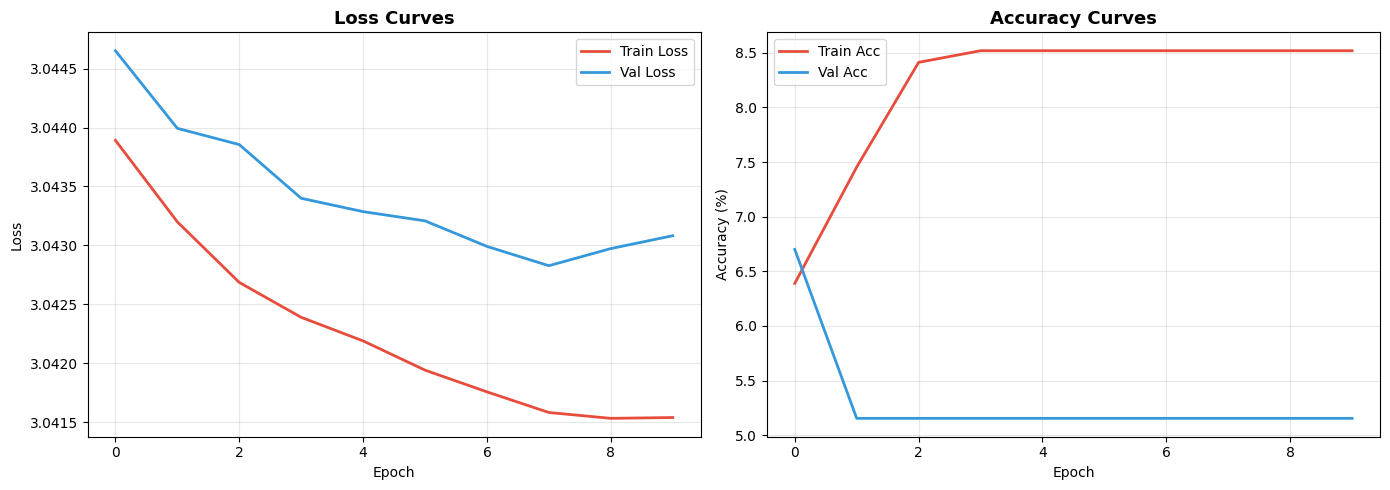

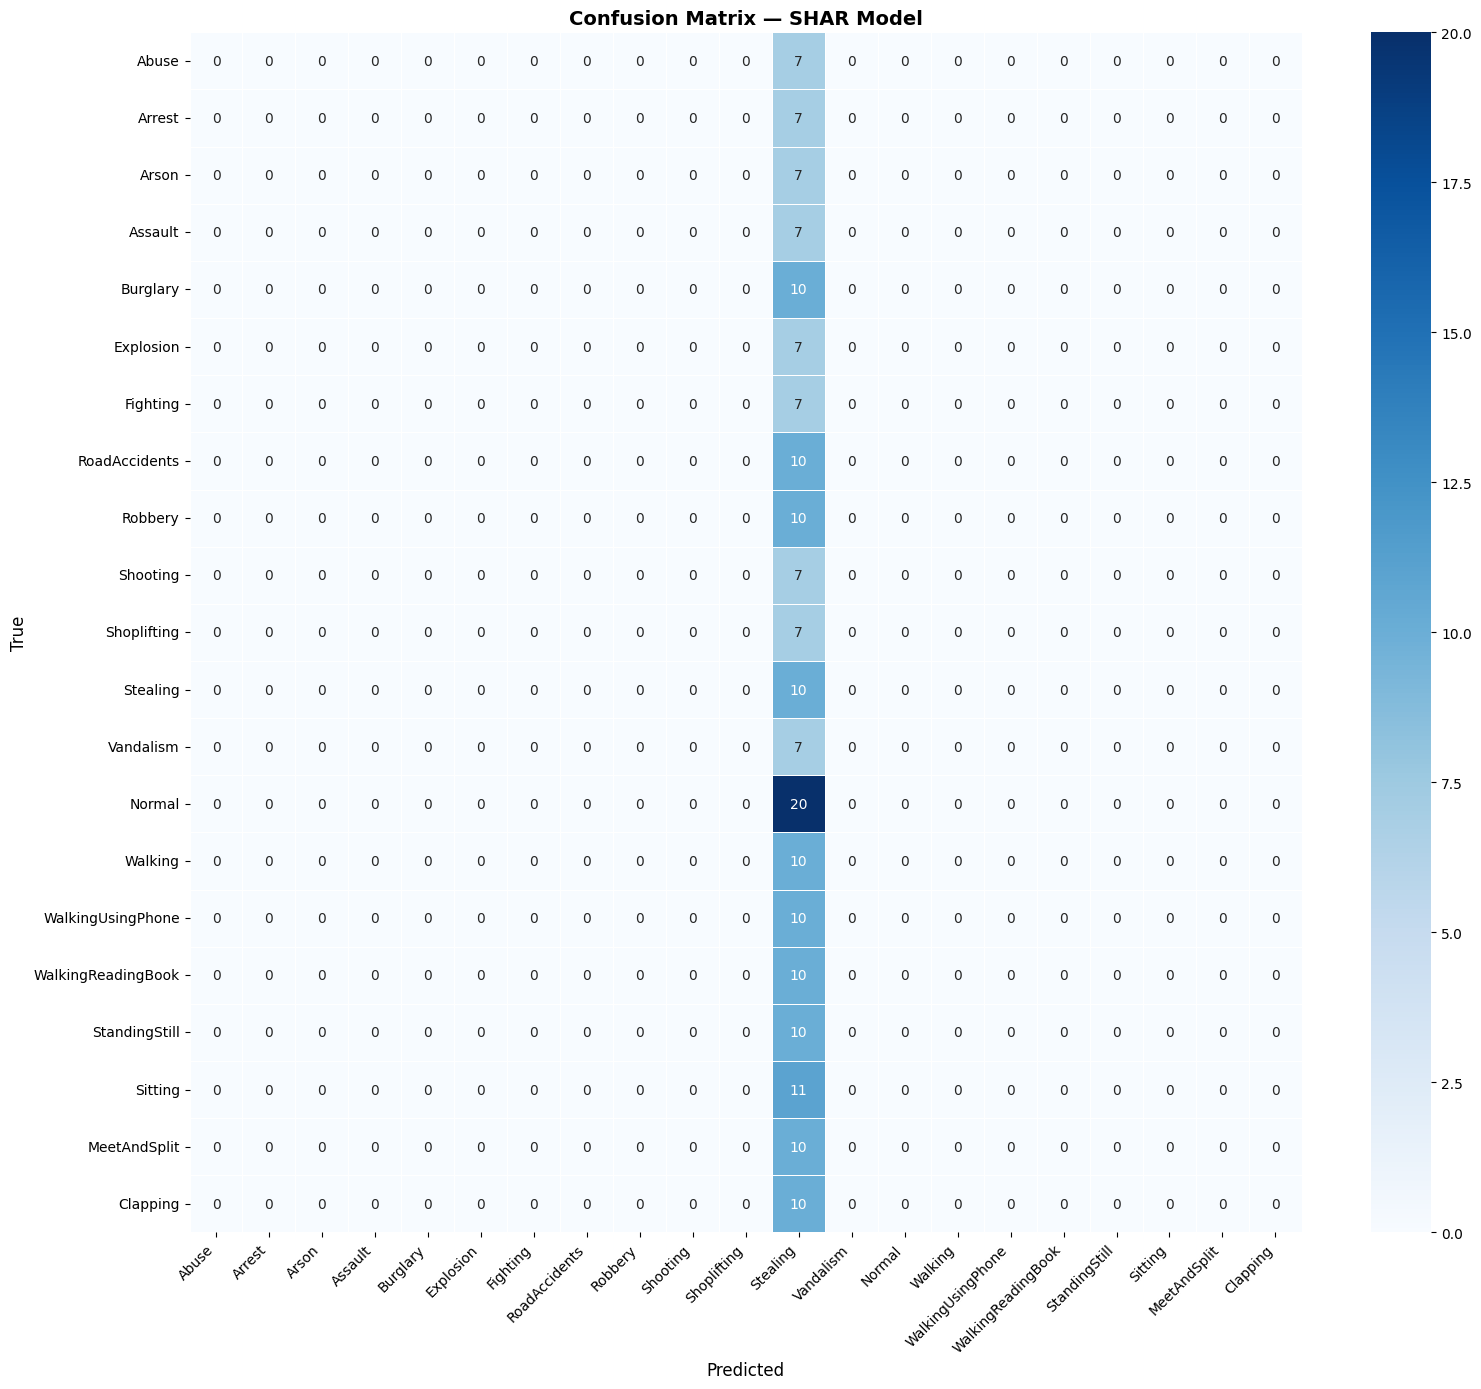

In [5]:
# ── Visualize Results ────────────────────────────────────
os.makedirs("../results/plots", exist_ok=True)
plot_training_curves(train_losses, val_losses, train_accs, val_accs,
                     save_path="../results/plots/cnn_lstm_curves.png")

# Confusion matrix on val set
cm = confusion_matrix(v_labels, v_preds)
plot_confusion_matrix(cm, CLASS_NAMES, save_path="../results/plots/cnn_lstm_val_cm.png")

print("\n📊 Classification Report:")
print(classification_report(v_labels, v_preds, target_names=CLASS_NAMES))
